First few rows of the dataset:
         Model      Pipeline    Dataset  Threshold     AUC  Accuracy  \
0  HeteroGATv2  No Balancing  TCGA Test      0.502  0.8952    0.7976   
1  HeteroGATv2  No Balancing       CGGA      0.502  0.7732    0.6364   
2        MOGAT  No Balancing  TCGA Test      0.554  0.9206    0.8512   
3        MOGAT  No Balancing       CGGA      0.554  0.7688    0.6748   
4     HyperTMO  No Balancing  TCGA Test      0.520  0.8245    0.5655   

   Precision  Recall_1  Recall_0      F1  
0     0.7143    0.8571    0.7551  0.7792  
1     0.4944    0.8725    0.5054  0.6312  
2     0.7848    0.8857    0.8265  0.8322  
3     0.5287    0.8137    0.5978  0.6409  
4     0.4894    0.9857    0.2653  0.6540  

Dataset shape: (56, 10)

Unique models: <StringArray>
['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']
Length: 7, dtype: str

Unique pipelines: <StringArray>
['No Balancing', 'SMOTE', 'CTGAN', 'ROS']
Length: 4, dtype: str

Models: <StringArray>
['Het

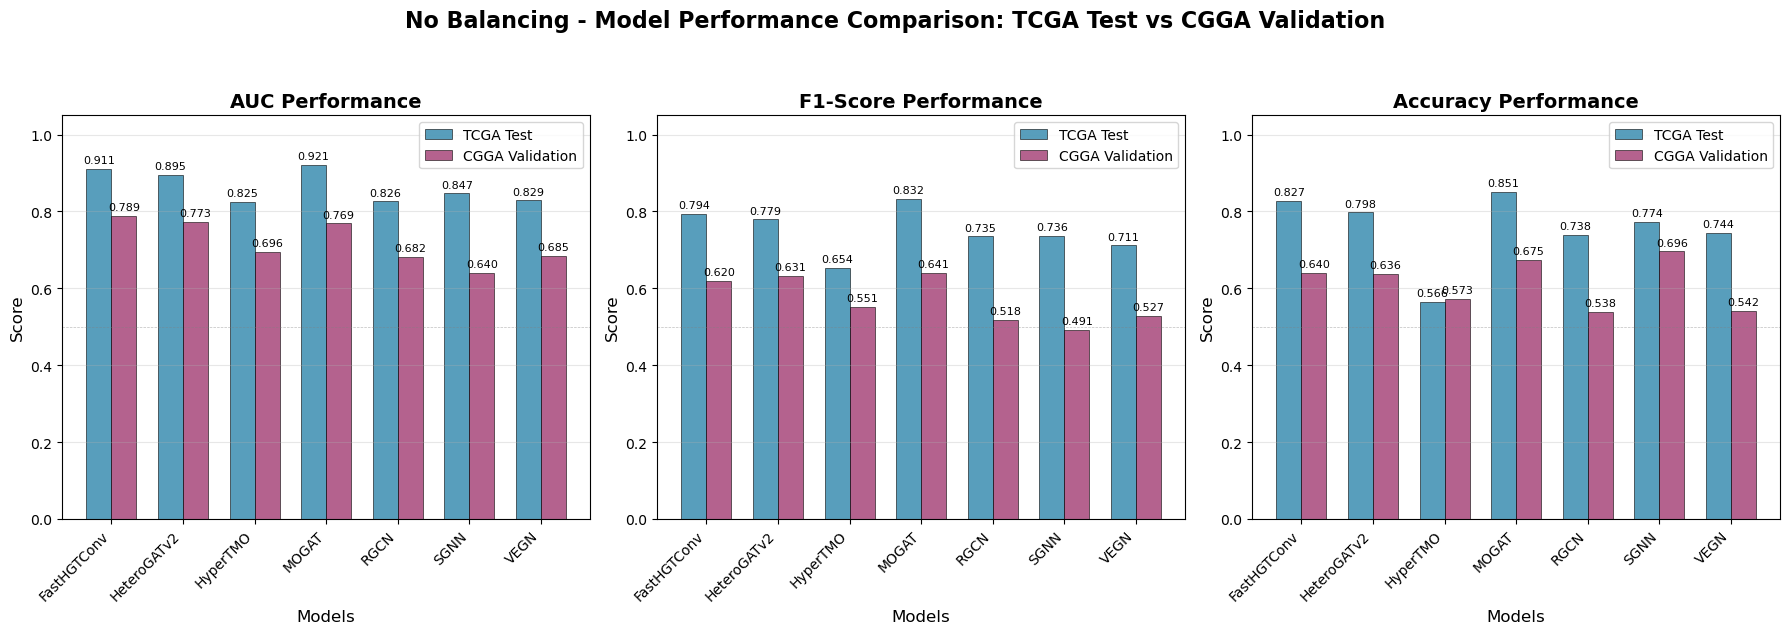

   - SMOTE


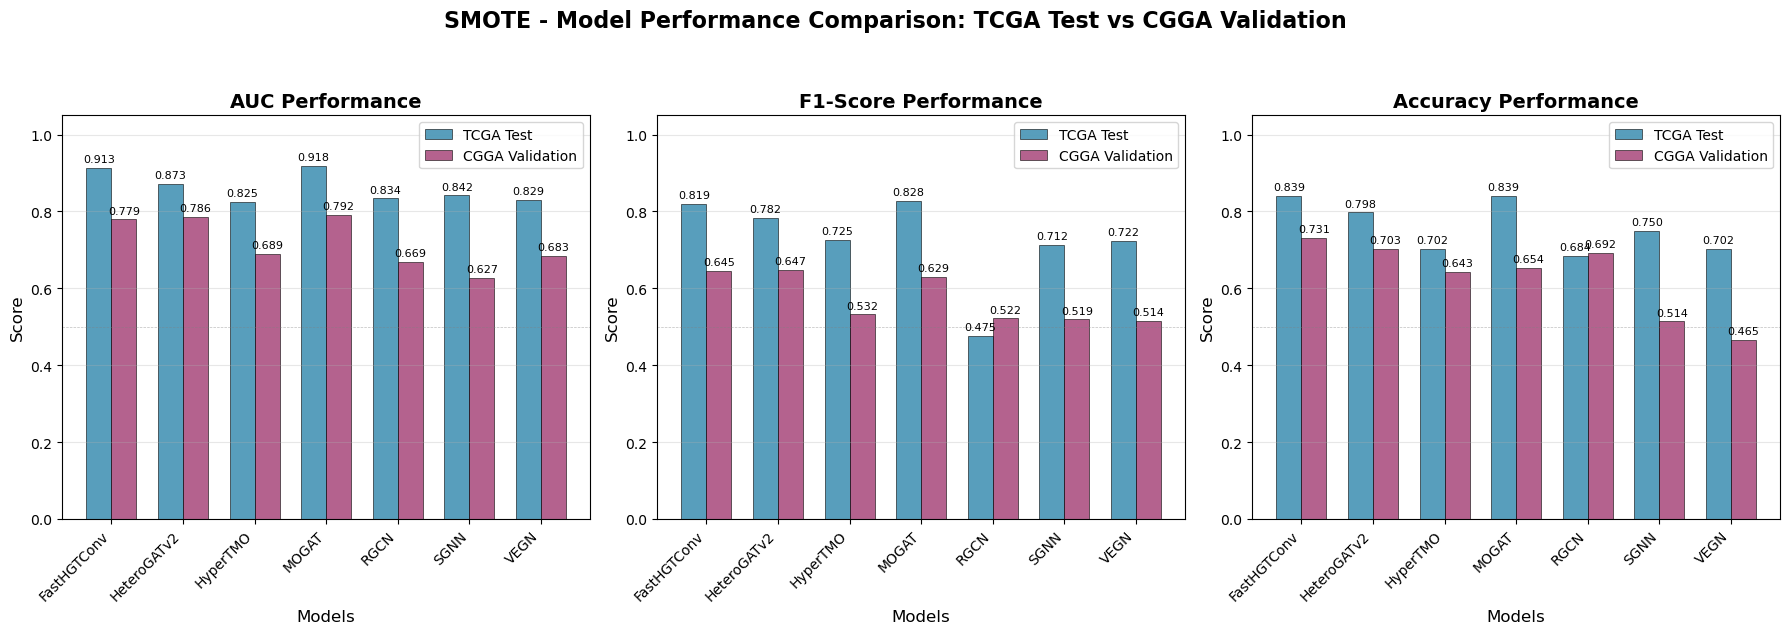

   - CTGAN


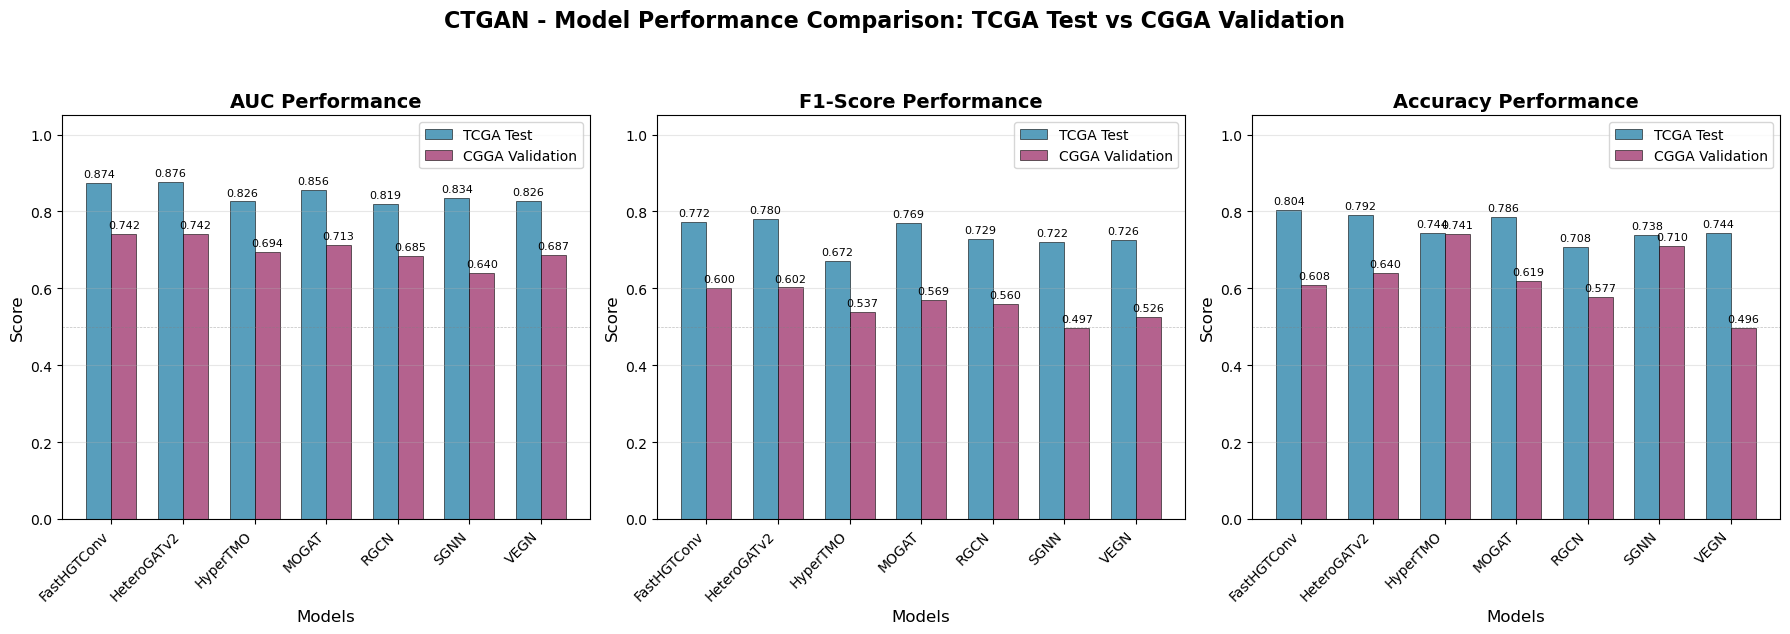

   - ROS


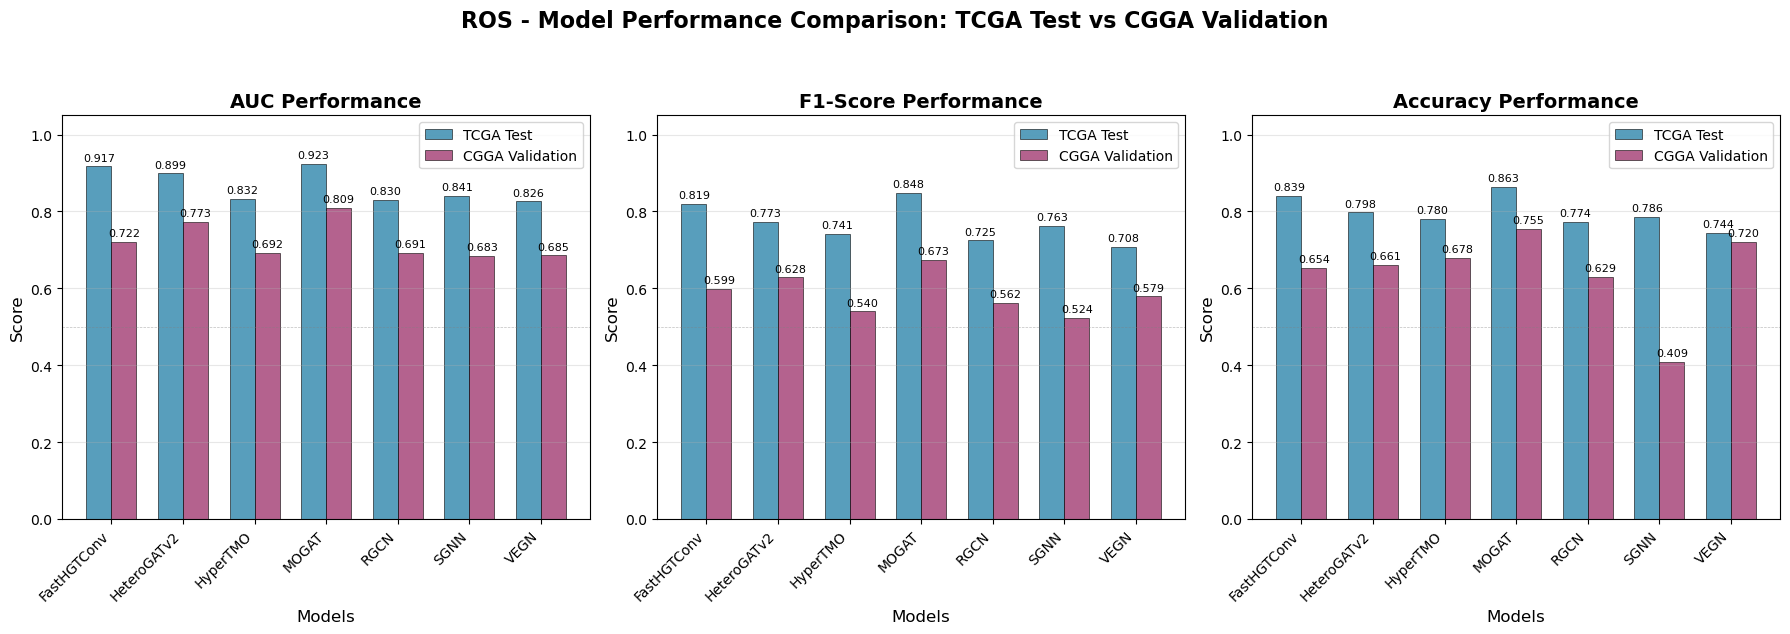


2. Plotting all pipelines with all metrics in one figure...


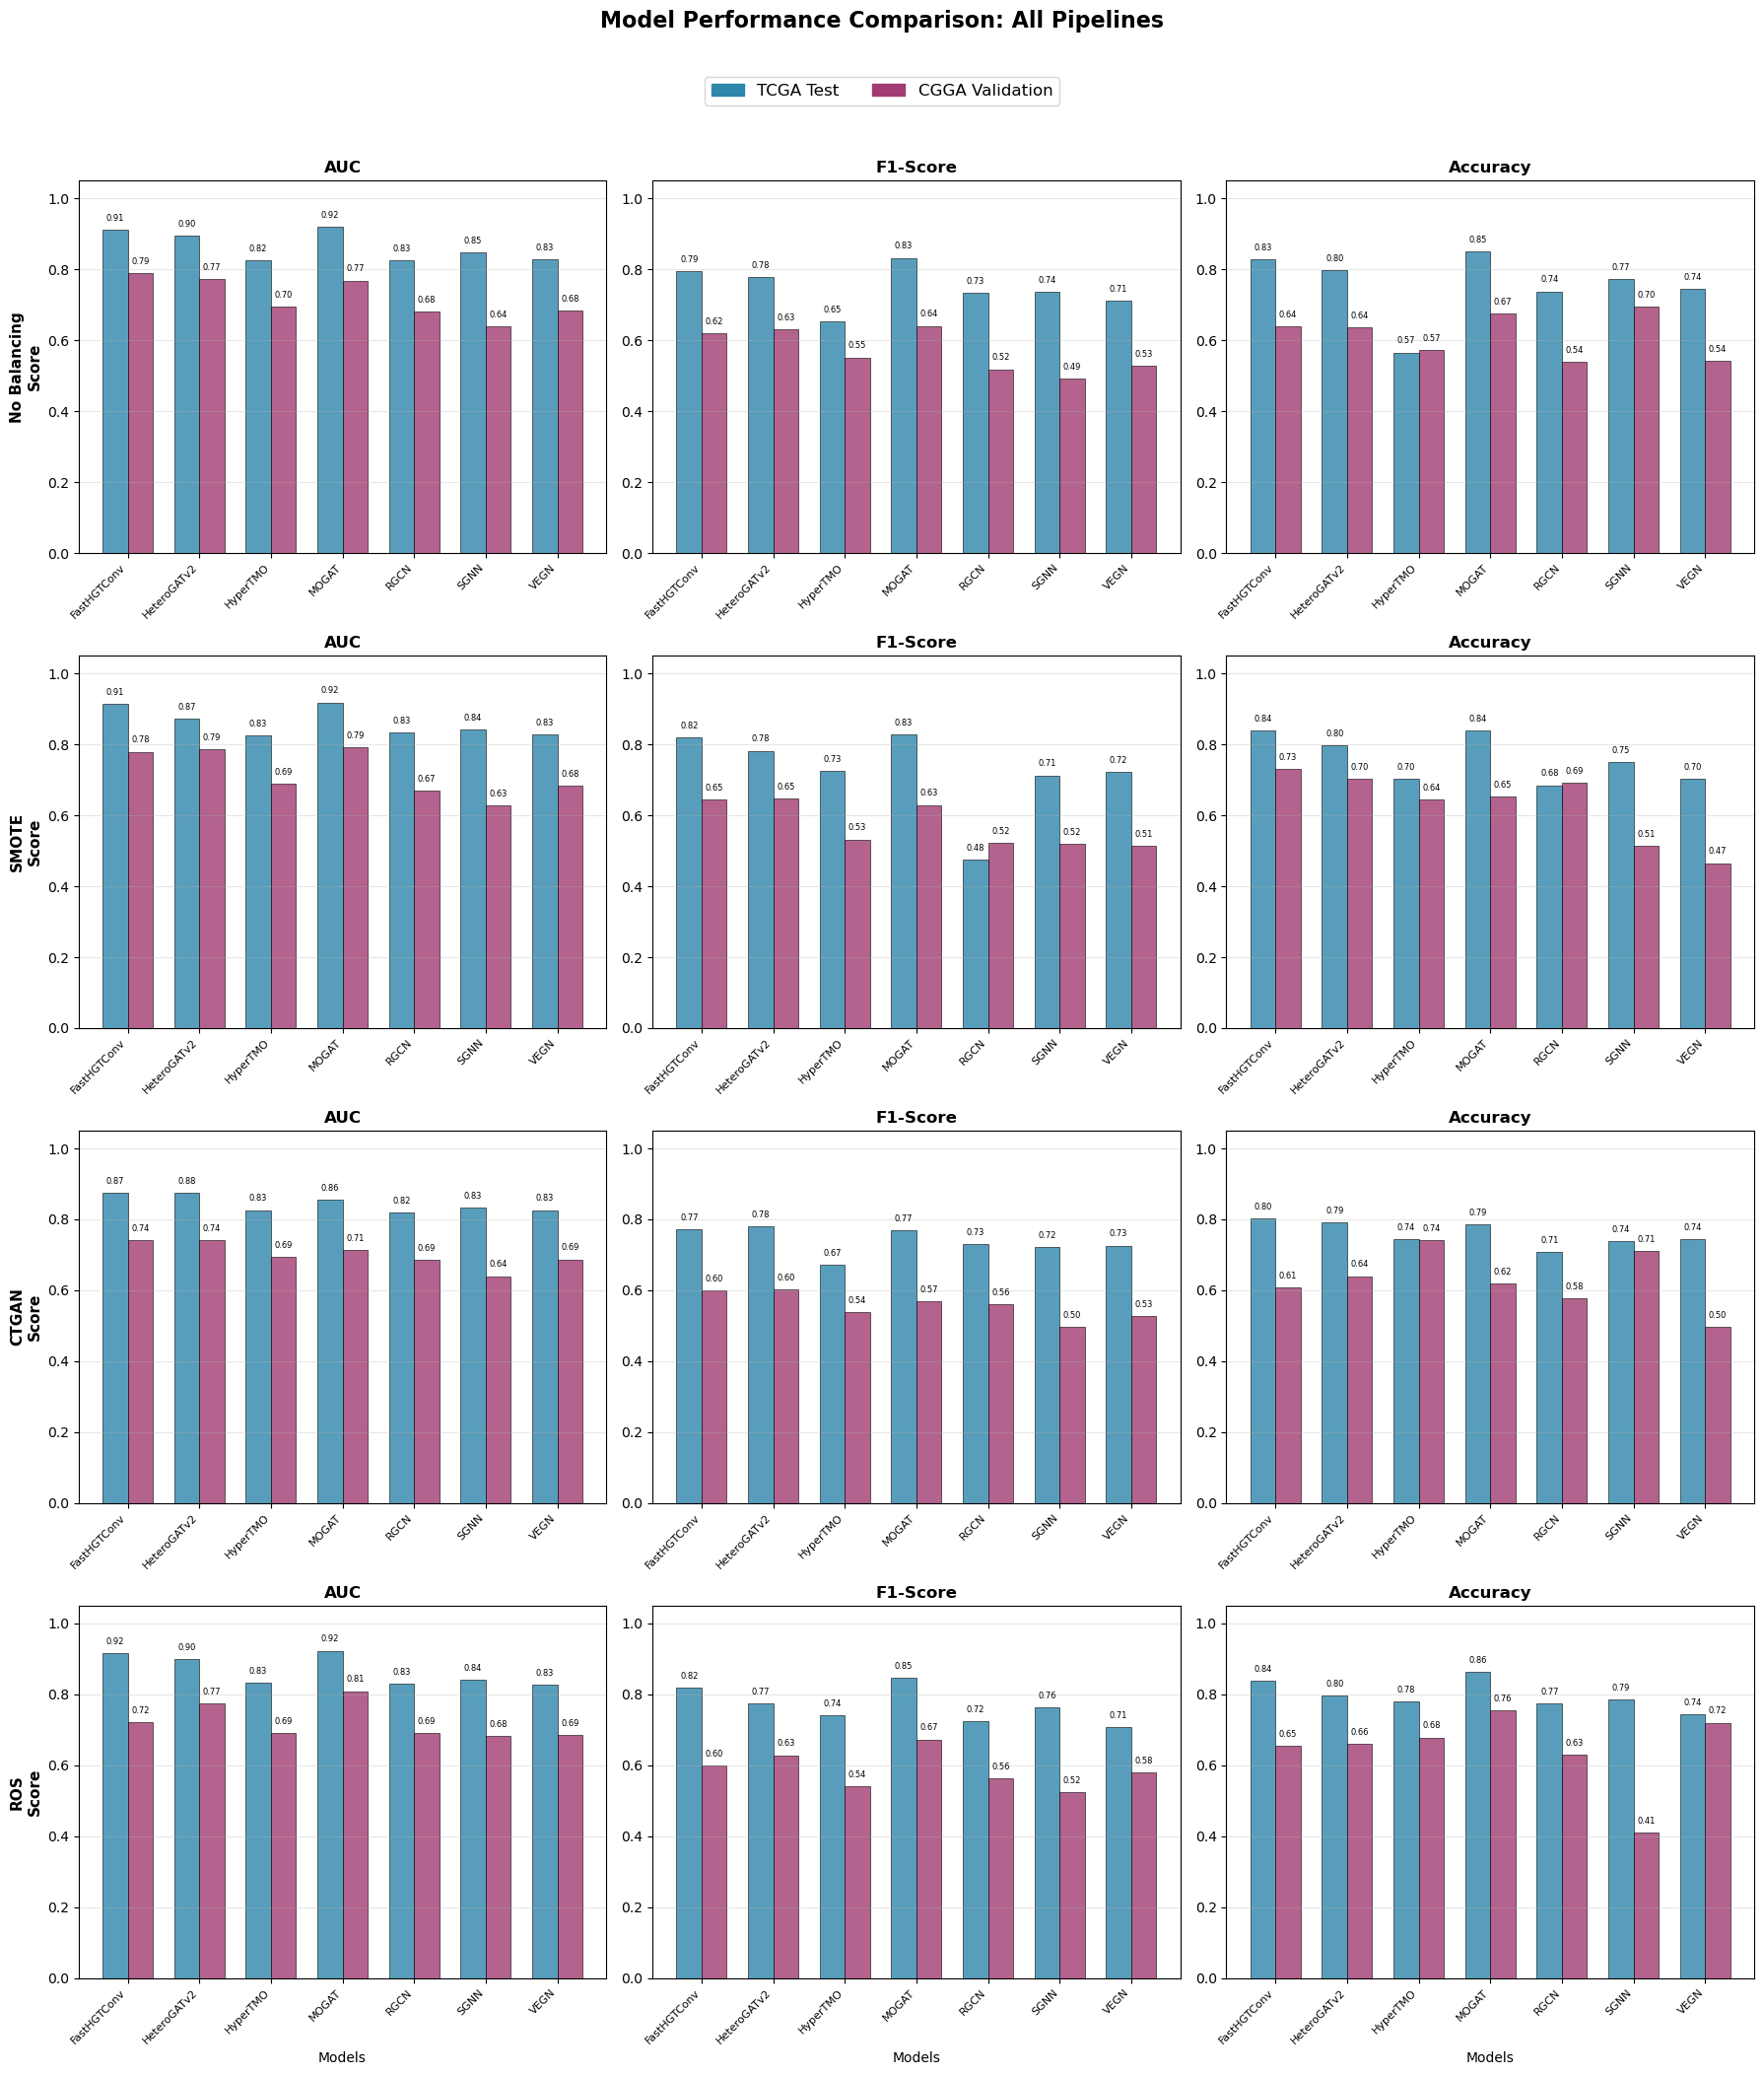


3. Creating summary heatmap...


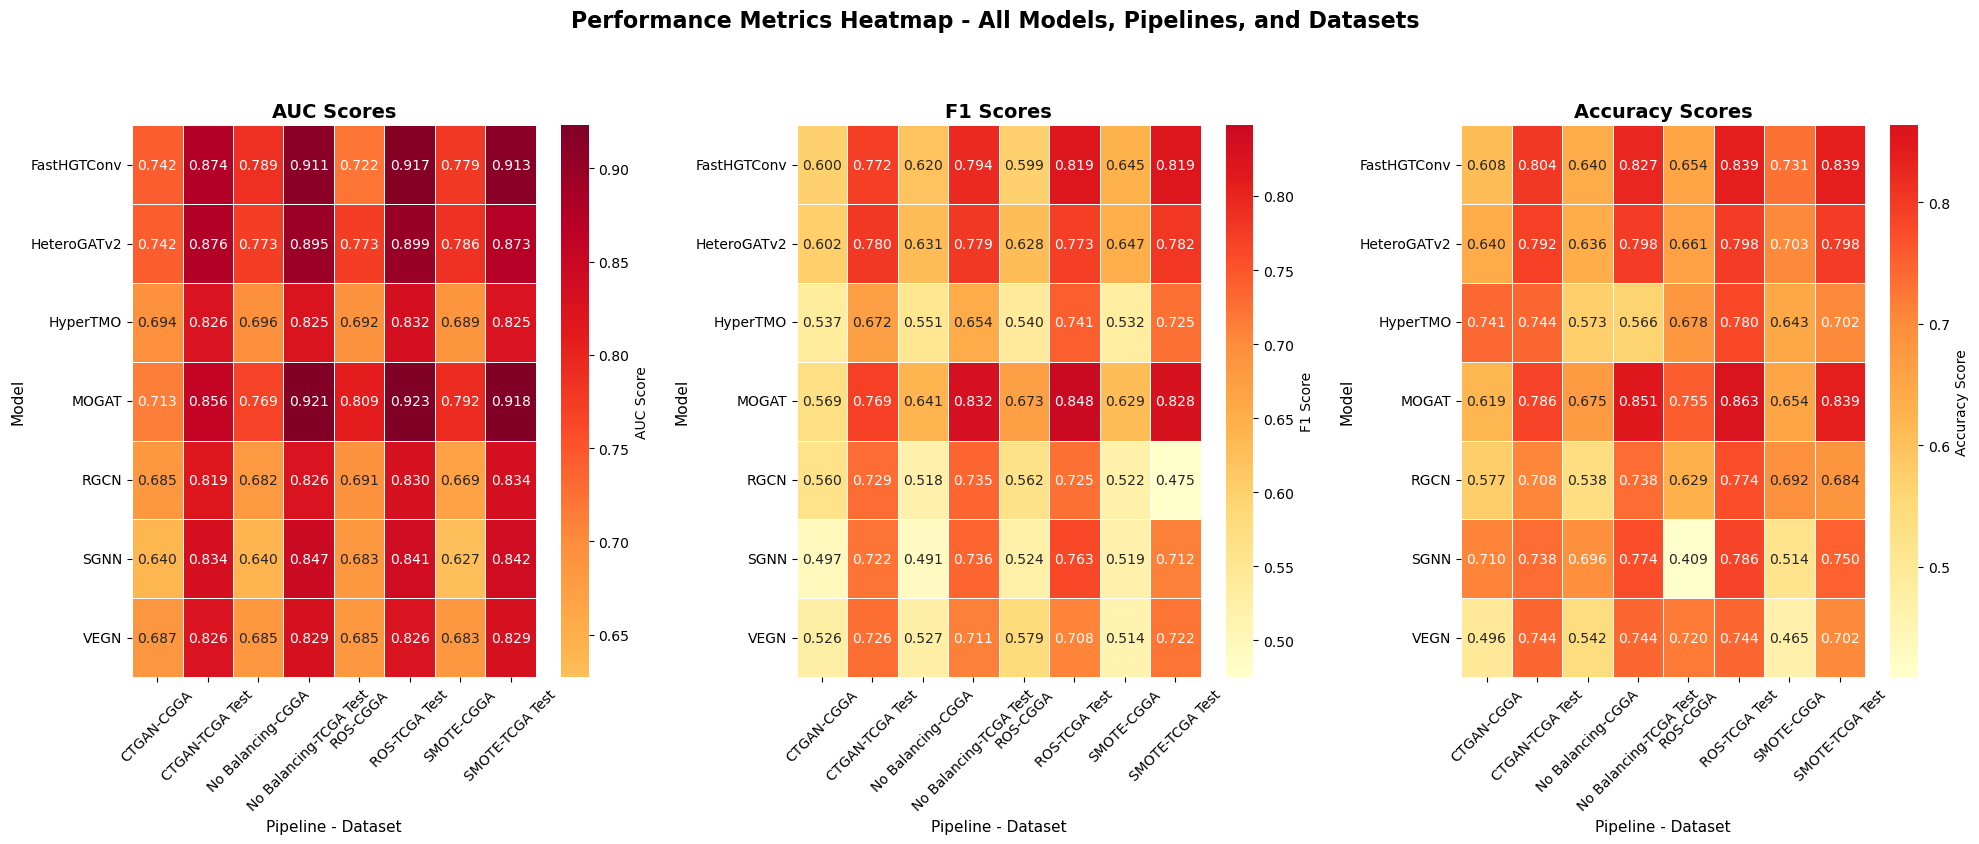


4. Creating radar chart for best models...


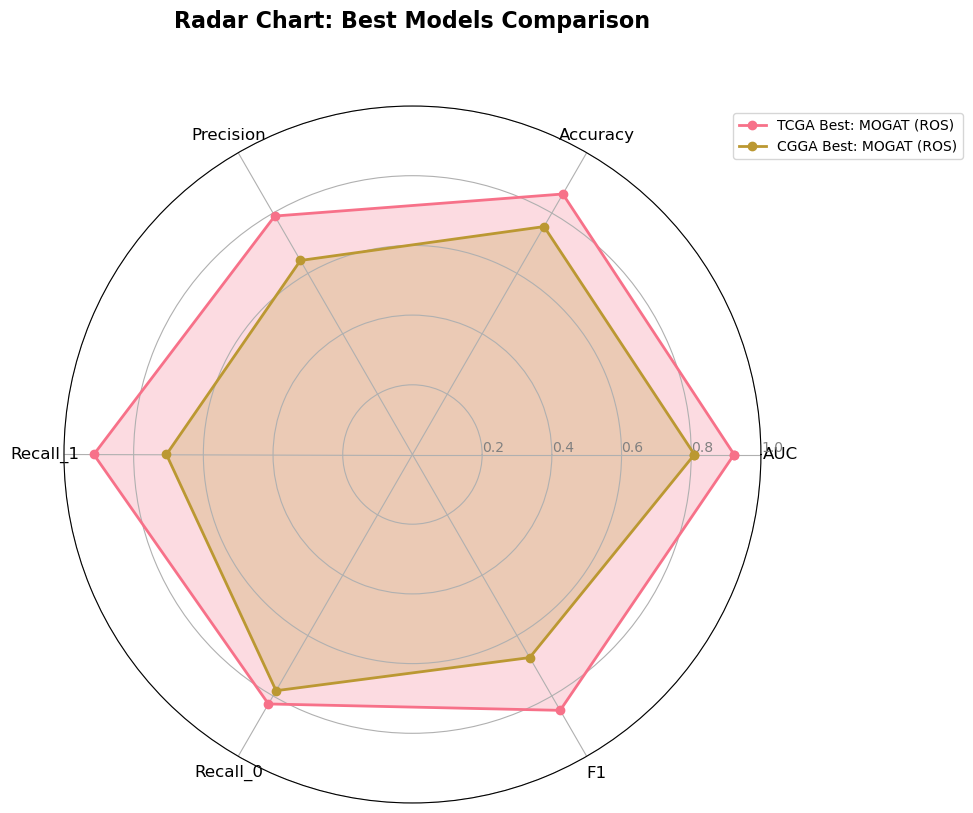


SUMMARY STATISTICS

Best Models:
TCGA Test Best: MOGAT (ROS)
  AUC: 0.9230, F1: 0.8477, Accuracy: 0.8631
CGGA Validation Best: MOGAT (ROS)
  AUC: 0.8092, F1: 0.6729, Accuracy: 0.7552

Average Performance by Model (across all pipelines and datasets):
                AUC      F1  Accuracy
Model                                
FastHGTConv  0.8309  0.7086    0.7428
HeteroGATv2  0.8271  0.7030    0.7280
HyperTMO     0.7598  0.6192    0.6785
MOGAT        0.8377  0.7237    0.7552
RGCN         0.7545  0.6032    0.6677
SGNN         0.7442  0.6205    0.6720
VEGN         0.7564  0.6267    0.6448

Average Performance by Pipeline (across all models and datasets):
                 AUC      F1  Accuracy
Pipeline                              
CTGAN         0.7725  0.6473    0.6934
No Balancing  0.7919  0.6587    0.6856
ROS           0.7945  0.6773    0.7207
SMOTE         0.7900  0.6480    0.6941

VISUALIZATION COMPLETE

Generated files:
1. [Pipeline]_all_metrics.png - One file per pipeline with 3 sub

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualization
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Read the CSV file
df = pd.read_csv('../V15_results_final.csv')

# Display the first few rows to verify data
print("First few rows of the dataset:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nUnique models:", df['Model'].unique())
print("\nUnique pipelines:", df['Pipeline'].unique())

# Get unique models (7 models)
models = df['Model'].unique()
print("\nModels:", models)

# Create function to plot all three metrics in one figure
def plot_all_metrics_one_fig(df, pipeline_name):
    """
    Create a single figure with three subplots for AUC, F1-score, and Accuracy
    for a specific pipeline
    """
    # Filter data for the specific pipeline
    pipeline_df = df[df['Pipeline'] == pipeline_name]
    
    # Separate TCGA and CGGA data
    tcga_data = pipeline_df[pipeline_df['Dataset'] == 'TCGA Test']
    cgga_data = pipeline_df[pipeline_df['Dataset'] == 'CGGA']
    
    # Merge data for comparison
    merged_data = pd.merge(
        tcga_data[['Model', 'AUC', 'F1', 'Accuracy']],
        cgga_data[['Model', 'AUC', 'F1', 'Accuracy']],
        on='Model',
        suffixes=('_TCGA', '_CGGA')
    )
    
    # Sort by model for consistent ordering
    merged_data = merged_data.sort_values('Model')
    
    # Set up the plot with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Define colors
    colors = ['#2E86AB', '#A23B72']  # Blue for TCGA, Purple for CGGA
    
    # Metrics to plot
    metrics = ['AUC', 'F1', 'Accuracy']
    titles = ['AUC Performance', 'F1-Score Performance', 'Accuracy Performance']
    
    x = np.arange(len(merged_data))
    width = 0.35
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        # Create bars
        bars1 = axes[idx].bar(x - width/2, merged_data[f'{metric}_TCGA'], 
                              width, label='TCGA Test', color=colors[0], alpha=0.8, 
                              edgecolor='black', linewidth=0.5)
        bars2 = axes[idx].bar(x + width/2, merged_data[f'{metric}_CGGA'], 
                              width, label='CGGA Validation', color=colors[1], alpha=0.8,
                              edgecolor='black', linewidth=0.5)
        
        # Customize the plot
        axes[idx].set_xlabel('Models', fontsize=12)
        axes[idx].set_ylabel('Score', fontsize=12)
        axes[idx].set_title(f'{title}', fontsize=14, fontweight='bold')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(merged_data['Model'], rotation=45, ha='right', fontsize=10)
        axes[idx].legend(loc='upper right', fontsize=10)
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].set_ylim(0, 1.05)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                              f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=0)
        
        # Add a horizontal line at 0.5 for reference
        axes[idx].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    plt.suptitle(f'{pipeline_name} - Model Performance Comparison: TCGA Test vs CGGA Validation', 
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'{pipeline_name}_all_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return merged_data

# Create function to plot all pipelines combined in one figure
def plot_all_pipelines_all_metrics(df):
    """
    Create a comprehensive figure with all pipelines and all metrics
    """
    pipelines = df['Pipeline'].unique()
    metrics = ['AUC', 'F1', 'Accuracy']
    metric_titles = ['AUC', 'F1-Score', 'Accuracy']
    
    # Set up the plot: rows = pipelines, columns = metrics
    fig, axes = plt.subplots(len(pipelines), len(metrics), figsize=(18, 5*len(pipelines)))
    
    # Define colors
    colors = ['#2E86AB', '#A23B72']
    
    for i, pipeline in enumerate(pipelines):
        # Filter data for the pipeline
        pipeline_df = df[df['Pipeline'] == pipeline]
        
        # Separate TCGA and CGGA data
        tcga_data = pipeline_df[pipeline_df['Dataset'] == 'TCGA Test']
        cgga_data = pipeline_df[pipeline_df['Dataset'] == 'CGGA']
        
        # Merge data
        merged_data = pd.merge(
            tcga_data[['Model', 'AUC', 'F1', 'Accuracy']],
            cgga_data[['Model', 'AUC', 'F1', 'Accuracy']],
            on='Model',
            suffixes=('_TCGA', '_CGGA')
        ).sort_values('Model')
        
        x = np.arange(len(merged_data))
        width = 0.35
        
        for j, metric in enumerate(metrics):
            ax = axes[i, j] if len(pipelines) > 1 else axes[j]
            
            # Create bars
            bars1 = ax.bar(x - width/2, merged_data[f'{metric}_TCGA'], 
                          width, label='TCGA Test' if i==0 and j==0 else "", 
                          color=colors[0], alpha=0.8, edgecolor='black', linewidth=0.5)
            bars2 = ax.bar(x + width/2, merged_data[f'{metric}_CGGA'], 
                          width, label='CGGA Validation' if i==0 and j==0 else "", 
                          color=colors[1], alpha=0.8, edgecolor='black', linewidth=0.5)
            
            # Customize
            if i == len(pipelines)-1:
                ax.set_xlabel('Models', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{pipeline}\nScore', fontsize=11, fontweight='bold')
            
            ax.set_title(f'{metric_titles[j]}', fontsize=12, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(merged_data['Model'], rotation=45, ha='right', fontsize=8)
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim(0, 1.05)
            
            # Add value labels (only for some to avoid clutter)
            if len(merged_data) <= 7:  # Only add labels if not too many models
                for bars in [bars1, bars2]:
                    for bar in bars:
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                               f'{height:.2f}', ha='center', va='bottom', fontsize=6)
    
    # Add legend
    handles = [plt.Rectangle((0,0),1,1, color=colors[0]), 
               plt.Rectangle((0,0),1,1, color=colors[1])]
    labels = ['TCGA Test', 'CGGA Validation']
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
              ncol=2, fontsize=12)
    
    plt.suptitle('Model Performance Comparison: All Pipelines', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('all_pipelines_all_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create function to plot summary heatmap
def plot_summary_heatmap(df):
    """
    Create a heatmap showing all metrics for all models and pipelines
    """
    # Prepare data for heatmap
    metrics = ['AUC', 'F1', 'Accuracy']
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    for idx, metric in enumerate(metrics):
        # Pivot data for the metric
        pivot_data = df.pivot_table(
            values=metric, 
            index='Model', 
            columns=['Pipeline', 'Dataset'], 
            aggfunc='mean'
        )
        
        # Create heatmap
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                   center=0.7, linewidths=0.5, ax=axes[idx],
                   cbar_kws={'label': f'{metric} Score'})
        
        axes[idx].set_title(f'{metric} Scores', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Pipeline - Dataset', fontsize=11)
        axes[idx].set_ylabel('Model', fontsize=11)
        
        # Rotate x-axis labels
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Performance Metrics Heatmap - All Models, Pipelines, and Datasets', 
                fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('metrics_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main execution
print("\n" + "="*60)
print("GENERATING COMPREHENSIVE VISUALIZATIONS")
print("="*60)

# 1. Plot all metrics for each pipeline in one figure
print("\n1. Plotting all metrics for each pipeline...")
pipelines = df['Pipeline'].unique()
for pipeline in pipelines:
    print(f"   - {pipeline}")
    plot_all_metrics_one_fig(df, pipeline)

# 2. Plot all pipelines with all metrics in one comprehensive figure
print("\n2. Plotting all pipelines with all metrics in one figure...")
plot_all_pipelines_all_metrics(df)

# 3. Create summary heatmap
print("\n3. Creating summary heatmap...")
plot_summary_heatmap(df)

# 4. Create a radar chart for the best performing model in each dataset
def plot_radar_comparison(df):
    """
    Create a radar chart comparing the best models
    """
    from math import pi
    
    # Find best models for TCGA and CGGA
    best_tcga = df[df['Dataset'] == 'TCGA Test'].loc[df[df['Dataset'] == 'TCGA Test']['AUC'].idxmax()]
    best_cgga = df[df['Dataset'] == 'CGGA'].loc[df[df['Dataset'] == 'CGGA']['AUC'].idxmax()]
    
    # Categories
    categories = ['AUC', 'Accuracy', 'Precision', 'Recall_1', 'Recall_0', 'F1']
    N = len(categories)
    
    # Values for the two best models
    values_tcga = [best_tcga[cat] for cat in categories]
    values_cgga = [best_cgga[cat] for cat in categories]
    
    # Repeat first value to close the circle
    values_tcga += values_tcga[:1]
    values_cgga += values_cgga[:1]
    
    # Angles for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Draw axes
    plt.xticks(angles[:-1], categories, size=12)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], 
               color="grey", size=10)
    plt.ylim(0, 1)
    
    # Plot data
    ax.plot(angles, values_tcga, 'o-', linewidth=2, label=f"TCGA Best: {best_tcga['Model']} ({best_tcga['Pipeline']})")
    ax.fill(angles, values_tcga, alpha=0.25)
    
    ax.plot(angles, values_cgga, 'o-', linewidth=2, label=f"CGGA Best: {best_cgga['Model']} ({best_cgga['Pipeline']})")
    ax.fill(angles, values_cgga, alpha=0.25)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.title('Radar Chart: Best Models Comparison', size=16, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return best_tcga, best_cgga

print("\n4. Creating radar chart for best models...")
best_tcga, best_cgga = plot_radar_comparison(df)

# 5. Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nBest Models:")
print(f"TCGA Test Best: {best_tcga['Model']} ({best_tcga['Pipeline']})")
print(f"  AUC: {best_tcga['AUC']:.4f}, F1: {best_tcga['F1']:.4f}, Accuracy: {best_tcga['Accuracy']:.4f}")
print(f"CGGA Validation Best: {best_cgga['Model']} ({best_cgga['Pipeline']})")
print(f"  AUC: {best_cgga['AUC']:.4f}, F1: {best_cgga['F1']:.4f}, Accuracy: {best_cgga['Accuracy']:.4f}")

# Calculate average performance by model
print("\nAverage Performance by Model (across all pipelines and datasets):")
model_avg = df.groupby('Model')[['AUC', 'F1', 'Accuracy']].mean().round(4)
print(model_avg)

# Calculate average performance by pipeline
print("\nAverage Performance by Pipeline (across all models and datasets):")
pipeline_avg = df.groupby('Pipeline')[['AUC', 'F1', 'Accuracy']].mean().round(4)
print(pipeline_avg)

print("\n" + "="*60)
print("VISUALIZATION COMPLETE")
print("="*60)
print("\nGenerated files:")
print("1. [Pipeline]_all_metrics.png - One file per pipeline with 3 subplots (AUC, F1, Accuracy)")
print("2. all_pipelines_all_metrics.png - Comprehensive figure with all pipelines and metrics")
print("3. metrics_heatmap.png - Heatmap showing all metrics")
print("4. radar_comparison.png - Radar chart comparing best models")

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# Read the CSV file
#df = pd.read_csv('V15_results_final.csv')

# Display the first few rows to verify data
print("First few rows of the dataset:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nUnique models:", df['Model'].unique())
print("\nUnique pipelines:", df['Pipeline'].unique())

# Get unique values
pipelines = df['Pipeline'].unique()
models = df['Model'].unique()
datasets = ['TCGA Test', 'CGGA']

print("="*100)
print("PERFORMANCE METRICS FOR ALL MODELS".center(100))
print("="*100)

# Create a dictionary to store all tables
all_tables = {}

# 1. Create tables for each pipeline
for pipeline in pipelines:
    print(f"\n\n{'='*80}")
    print(f"{pipeline} PIPELINE".center(80))
    print('='*80)
    
    # Filter data for this pipeline
    pipeline_df = df[df['Pipeline'] == pipeline].copy()
    
    # Create a formatted table
    table_data = []
    for model in models:
        model_data = pipeline_df[pipeline_df['Model'] == model]
        for dataset in datasets:
            dataset_data = model_data[model_data['Dataset'] == dataset]
            if not dataset_data.empty:
                row = dataset_data[['Model', 'Dataset', 'AUC', 'F1', 'Accuracy']].iloc[0]
                table_data.append(row)
    
    table_df = pd.DataFrame(table_data)
    
    # Sort by Model and Dataset
    table_df = table_df.sort_values(['Model', 'Dataset'])
    
    # Store in dictionary
    all_tables[pipeline] = table_df
    
    # Display as a formatted table using pandas
    print("\n", table_df.to_string(index=False))
    print("-" * 80)
    
    # Also display with formatting for better readability
    styled_df = table_df.style.background_gradient(cmap='YlOrRd', subset=['AUC', 'F1', 'Accuracy'])\
                          .format({'AUC': '{:.4f}', 'F1': '{:.4f}', 'Accuracy': '{:.4f}'})\
                          .set_properties(**{'text-align': 'center'})\
                          .set_table_styles([
                              {'selector': 'th', 
                               'props': [('font-weight', 'bold'), 
                                        ('text-align', 'center'),
                                        ('background-color', '#f0f0f0')]},
                              {'selector': 'td', 
                               'props': [('text-align', 'center')]}
                          ])
    display(styled_df)

# 2. Create a comprehensive summary table
print("\n\n" + "="*100)
print("COMPREHENSIVE SUMMARY TABLE (All Pipelines)".center(100))
print("="*100)

# Pivot the data for a comprehensive view
summary_data = []
for model in models:
    for pipeline in pipelines:
        for dataset in datasets:
            mask = (df['Model'] == model) & (df['Pipeline'] == pipeline) & (df['Dataset'] == dataset)
            if mask.any():
                row_data = df[mask].iloc[0]
                summary_data.append({
                    'Model': model,
                    'Pipeline': pipeline,
                    'Dataset': dataset,
                    'AUC': row_data['AUC'],
                    'F1': row_data['F1'],
                    'Accuracy': row_data['Accuracy']
                })

summary_df = pd.DataFrame(summary_data)

# Create pivot tables for better visualization
print("\nAUC Scores - All Pipelines and Datasets:")
pivot_auc = summary_df.pivot_table(values='AUC', index='Model', columns=['Pipeline', 'Dataset']).round(4)
print("\n", pivot_auc.to_string())
print("-" * 80)

print("\nF1-Score - All Pipelines and Datasets:")
pivot_f1 = summary_df.pivot_table(values='F1', index='Model', columns=['Pipeline', 'Dataset']).round(4)
print("\n", pivot_f1.to_string())
print("-" * 80)

print("\nAccuracy - All Pipelines and Datasets:")
pivot_acc = summary_df.pivot_table(values='Accuracy', index='Model', columns=['Pipeline', 'Dataset']).round(4)
print("\n", pivot_acc.to_string())
print("-" * 80)

# 3. Best performers table
print("\n\n" + "="*100)
print("BEST PERFORMERS BY METRIC AND DATASET".center(100))
print("="*100)

best_performers = []
metrics = ['AUC', 'F1', 'Accuracy']

for dataset in datasets:
    for metric in metrics:
        dataset_df = df[df['Dataset'] == dataset]
        best_idx = dataset_df[metric].idxmax()
        best = dataset_df.loc[best_idx]
        
        best_performers.append({
            'Dataset': dataset,
            'Metric': metric,
            'Best Model': best['Model'],
            'Pipeline': best['Pipeline'],
            'Score': best[metric]
        })

best_df = pd.DataFrame(best_performers)
print("\n", best_df.to_string(index=False))
print("="*80)

# Display best performers as styled table
styled_best = best_df.style.background_gradient(cmap='Greens', subset=['Score'])\
                    .format({'Score': '{:.4f}'})\
                    .set_properties(**{'text-align': 'center'})
display(styled_best)

# 4. Statistical summary by model
print("\n\n" + "="*100)
print("STATISTICAL SUMMARY BY MODEL".center(100))
print("="*100)

model_stats = df.groupby('Model').agg({
    'AUC': ['mean', 'std', 'min', 'max'],
    'F1': ['mean', 'std', 'min', 'max'],
    'Accuracy': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nModel Performance Statistics (across all pipelines and datasets):")
print("\n", model_stats.to_string())
print("="*80)

# 5. Statistical summary by pipeline
print("\n\n" + "="*100)
print("STATISTICAL SUMMARY BY PIPELINE".center(100))
print("="*100)

pipeline_stats = df.groupby('Pipeline').agg({
    'AUC': ['mean', 'std', 'min', 'max'],
    'F1': ['mean', 'std', 'min', 'max'],
    'Accuracy': ['mean', 'std', 'min', 'max']
}).round(4)

print("\nPipeline Performance Statistics (across all models and datasets):")
print("\n", pipeline_stats.to_string())
print("="*80)

# 6. Performance drop analysis
print("\n\n" + "="*100)
print("PERFORMANCE DROP: TCGA TEST → CGGA VALIDATION".center(100))
print("="*100)

comparison_data = []
for model in models:
    for pipeline in pipelines:
        tcga_mask = (df['Model'] == model) & (df['Pipeline'] == pipeline) & (df['Dataset'] == 'TCGA Test')
        cgga_mask = (df['Model'] == model) & (df['Pipeline'] == pipeline) & (df['Dataset'] == 'CGGA')
        
        if tcga_mask.any() and cgga_mask.any():
            tcga_row = df[tcga_mask].iloc[0]
            cgga_row = df[cgga_mask].iloc[0]
            
            auc_drop = tcga_row['AUC'] - cgga_row['AUC']
            f1_drop = tcga_row['F1'] - cgga_row['F1']
            acc_drop = tcga_row['Accuracy'] - cgga_row['Accuracy']
            
            comparison_data.append({
                'Model': model,
                'Pipeline': pipeline,
                'AUC Drop': auc_drop,
                'F1 Drop': f1_drop,
                'Accuracy Drop': acc_drop,
                'TCGA AUC': tcga_row['AUC'],
                'CGGA AUC': cgga_row['AUC']
            })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AUC Drop', ascending=False)

print("\nPerformance Drop (TCGA - CGGA) - Sorted by AUC Drop:")
print("\n", comparison_df.to_string(index=False))
print("="*80)

# 7. Summary table of best model for each pipeline
print("\n\n" + "="*100)
print("BEST MODEL FOR EACH PIPELINE".center(100))
print("="*100)

best_by_pipeline = []
for pipeline in pipelines:
    for dataset in datasets:
        pipeline_dataset_df = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == dataset)]
        best_idx = pipeline_dataset_df['AUC'].idxmax()
        best = pipeline_dataset_df.loc[best_idx]
        
        best_by_pipeline.append({
            'Pipeline': pipeline,
            'Dataset': dataset,
            'Best Model': best['Model'],
            'AUC': best['AUC'],
            'F1': best['F1'],
            'Accuracy': best['Accuracy']
        })

best_pipeline_df = pd.DataFrame(best_by_pipeline)
print("\n", best_pipeline_df.to_string(index=False))
print("="*80)

# 8. Export all tables to CSV files
print("\n\n" + "="*100)
print("EXPORTING TABLES TO CSV FILES".center(100))
print("="*100)

# Export individual pipeline tables
for pipeline in pipelines:
    filename = f'{pipeline.lower().replace(" ", "_")}_performance.csv'
    all_tables[pipeline].to_csv(filename, index=False)
    print(f"Exported: {filename}")

# Export summary tables
pivot_auc.to_csv('auc_summary.csv')
pivot_f1.to_csv('f1_summary.csv')
pivot_acc.to_csv('accuracy_summary.csv')
print("Exported: auc_summary.csv, f1_summary.csv, accuracy_summary.csv")

# Export best performers
best_df.to_csv('best_performers.csv', index=False)
print("Exported: best_performers.csv")

# Export comparison data
comparison_df.to_csv('performance_drop.csv', index=False)
print("Exported: performance_drop.csv")

# Export statistical summaries
model_stats.to_csv('model_statistics.csv')
pipeline_stats.to_csv('pipeline_statistics.csv')
print("Exported: model_statistics.csv, pipeline_statistics.csv")

# Export best by pipeline
best_pipeline_df.to_csv('best_by_pipeline.csv', index=False)
print("Exported: best_by_pipeline.csv")

print("\n" + "="*100)
print("TABLE GENERATION COMPLETE".center(100))
print("="*100)

# Display final summary
print("\n\n" + "="*100)
print("QUICK SUMMARY".center(100))
print("="*100)

print("\nTop 3 Models by Average AUC:")
top_models = df.groupby('Model')['AUC'].mean().sort_values(ascending=False).head(3)
for i, (model, auc) in enumerate(top_models.items(), 1):
    print(f"{i}. {model}: {auc:.4f}")

print("\nTop 3 Pipelines by Average AUC:")
top_pipelines = df.groupby('Pipeline')['AUC'].mean().sort_values(ascending=False)
for i, (pipeline, auc) in enumerate(top_pipelines.items(), 1):
    print(f"{i}. {pipeline}: {auc:.4f}")

print("\nBest Overall Model:")
best_overall = df.loc[df['AUC'].idxmax()]
print(f"Model: {best_overall['Model']}")
print(f"Pipeline: {best_overall['Pipeline']}")
print(f"Dataset: {best_overall['Dataset']}")
print(f"AUC: {best_overall['AUC']:.4f}")
print(f"F1: {best_overall['F1']:.4f}")
print(f"Accuracy: {best_overall['Accuracy']:.4f}")

print("\n" + "="*100)

First few rows of the dataset:
         Model      Pipeline    Dataset  Threshold     AUC  Accuracy  \
0  HeteroGATv2  No Balancing  TCGA Test      0.502  0.8952    0.7976   
1  HeteroGATv2  No Balancing       CGGA      0.502  0.7732    0.6364   
2        MOGAT  No Balancing  TCGA Test      0.554  0.9206    0.8512   
3        MOGAT  No Balancing       CGGA      0.554  0.7688    0.6748   
4     HyperTMO  No Balancing  TCGA Test      0.520  0.8245    0.5655   

   Precision  Recall_1  Recall_0      F1  
0     0.7143    0.8571    0.7551  0.7792  
1     0.4944    0.8725    0.5054  0.6312  
2     0.7848    0.8857    0.8265  0.8322  
3     0.5287    0.8137    0.5978  0.6409  
4     0.4894    0.9857    0.2653  0.6540  

Dataset shape: (56, 10)

Unique models: <StringArray>
['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']
Length: 7, dtype: str

Unique pipelines: <StringArray>
['No Balancing', 'SMOTE', 'CTGAN', 'ROS']
Length: 4, dtype: str
                            

,Model,Dataset,AUC,F1,Accuracy
11,FastHGTConv,CGGA,0.7886,0.6199,0.6399
10,FastHGTConv,TCGA Test,0.9115,0.7943,0.8274
1,HeteroGATv2,CGGA,0.7732,0.6312,0.6364
0,HeteroGATv2,TCGA Test,0.8952,0.7792,0.7976
5,HyperTMO,CGGA,0.6956,0.5515,0.5734
4,HyperTMO,TCGA Test,0.8245,0.6540,0.5655
3,MOGAT,CGGA,0.7688,0.6409,0.6748
2,MOGAT,TCGA Test,0.9206,0.8322,0.8512
7,RGCN,CGGA,0.6819,0.5182,0.5385
6,RGCN,TCGA Test,0.8259,0.7349,0.7381




                                 SMOTE PIPELINE                                 

       Model   Dataset    AUC     F1  Accuracy
FastHGTConv      CGGA 0.7793 0.6452    0.7308
FastHGTConv TCGA Test 0.9131 0.8188    0.8393
HeteroGATv2      CGGA 0.7863 0.6473    0.7028
HeteroGATv2 TCGA Test 0.8726 0.7821    0.7976
   HyperTMO      CGGA 0.6892 0.5321    0.6434
   HyperTMO TCGA Test 0.8251 0.7253    0.7024
      MOGAT      CGGA 0.7919 0.6292    0.6538
      MOGAT TCGA Test 0.9184 0.8280    0.8393
       RGCN      CGGA 0.6687 0.5217    0.6923
       RGCN TCGA Test 0.8338 0.4752    0.6845
       SGNN      CGGA 0.6273 0.5190    0.5140
       SGNN TCGA Test 0.8418 0.7123    0.7500
       VEGN      CGGA 0.6834 0.5143    0.4650
       VEGN TCGA Test 0.8289 0.7222    0.7024
--------------------------------------------------------------------------------


,Model,Dataset,AUC,F1,Accuracy
25,FastHGTConv,CGGA,0.7793,0.6452,0.7308
24,FastHGTConv,TCGA Test,0.9131,0.8188,0.8393
15,HeteroGATv2,CGGA,0.7863,0.6473,0.7028
14,HeteroGATv2,TCGA Test,0.8726,0.7821,0.7976
19,HyperTMO,CGGA,0.6892,0.5321,0.6434
18,HyperTMO,TCGA Test,0.8251,0.7253,0.7024
17,MOGAT,CGGA,0.7919,0.6292,0.6538
16,MOGAT,TCGA Test,0.9184,0.8280,0.8393
21,RGCN,CGGA,0.6687,0.5217,0.6923
20,RGCN,TCGA Test,0.8338,0.4752,0.6845




                                 CTGAN PIPELINE                                 

       Model   Dataset    AUC     F1  Accuracy
FastHGTConv      CGGA 0.7418 0.6000    0.6084
FastHGTConv TCGA Test 0.8742 0.7724    0.8036
HeteroGATv2      CGGA 0.7417 0.6023    0.6399
HeteroGATv2 TCGA Test 0.8758 0.7799    0.7917
   HyperTMO      CGGA 0.6937 0.5375    0.7413
   HyperTMO TCGA Test 0.8262 0.6718    0.7440
      MOGAT      CGGA 0.7133 0.5692    0.6189
      MOGAT TCGA Test 0.8564 0.7692    0.7857
       RGCN      CGGA 0.6852 0.5600    0.5769
       RGCN TCGA Test 0.8188 0.7293    0.7083
       SGNN      CGGA 0.6398 0.4970    0.7098
       SGNN TCGA Test 0.8341 0.7215    0.7381
       VEGN      CGGA 0.6873 0.5263    0.4965
       VEGN TCGA Test 0.8264 0.7261    0.7440
--------------------------------------------------------------------------------


...



                                  ROS PIPELINE                                  

       Model   Dataset    AUC     F1  Accuracy
FastHGTConv      CGGA 0.7215 0.5992    0.6538
FastHGTConv TCGA Test 0.9171 0.8188    0.8393
HeteroGATv2      CGGA 0.7734 0.6284    0.6608
HeteroGATv2 TCGA Test 0.8987 0.7733    0.7976
   HyperTMO      CGGA 0.6915 0.5400    0.6783
   HyperTMO TCGA Test 0.8324 0.7413    0.7798
      MOGAT      CGGA 0.8092 0.6729    0.7552
      MOGAT TCGA Test 0.9230 0.8477    0.8631
       RGCN      CGGA 0.6911 0.5620    0.6294
       RGCN TCGA Test 0.8303 0.7246    0.7738
       SGNN      CGGA 0.6833 0.5239    0.4091
       SGNN TCGA Test 0.8405 0.7632    0.7857
       VEGN      CGGA 0.6855 0.5789    0.7203
       VEGN TCGA Test 0.8261 0.7075    0.7440
--------------------------------------------------------------------------------


,Model,Dataset,AUC,F1,Accuracy
53,FastHGTConv,CGGA,0.7215,0.5992,0.6538
52,FastHGTConv,TCGA Test,0.9171,0.8188,0.8393
43,HeteroGATv2,CGGA,0.7734,0.6284,0.6608
42,HeteroGATv2,TCGA Test,0.8987,0.7733,0.7976
47,HyperTMO,CGGA,0.6915,0.5400,0.6783
46,HyperTMO,TCGA Test,0.8324,0.7413,0.7798
45,MOGAT,CGGA,0.8092,0.6729,0.7552
44,MOGAT,TCGA Test,0.9230,0.8477,0.8631
49,RGCN,CGGA,0.6911,0.5620,0.6294
48,RGCN,TCGA Test,0.8303,0.7246,0.7738




                            COMPREHENSIVE SUMMARY TABLE (All Pipelines)                             

AUC Scores - All Pipelines and Datasets:

 Pipeline      CTGAN           No Balancing               ROS             SMOTE          
Dataset        CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test    CGGA TCGA Test
Model                                                                                   
FastHGTConv  0.7418    0.8742       0.7886    0.9115  0.7215    0.9171  0.7793    0.9131
HeteroGATv2  0.7417    0.8758       0.7732    0.8952  0.7734    0.8987  0.7863    0.8726
HyperTMO     0.6937    0.8262       0.6956    0.8245  0.6915    0.8324  0.6892    0.8251
MOGAT        0.7133    0.8564       0.7688    0.9206  0.8092    0.9230  0.7919    0.9184
RGCN         0.6852    0.8188       0.6819    0.8259  0.6911    0.8303  0.6687    0.8338
SGNN         0.6398    0.8341       0.6401    0.8469  0.6833    0.8405  0.6273    0.8418
VEGN         0.6873    0.8264       0.6847    0.8287

,Dataset,Metric,Best Model,Pipeline,Score
0,TCGA Test,AUC,MOGAT,ROS,0.9230
1,TCGA Test,F1,MOGAT,ROS,0.8477
2,TCGA Test,Accuracy,MOGAT,ROS,0.8631
3,CGGA,AUC,MOGAT,ROS,0.8092
4,CGGA,F1,MOGAT,ROS,0.6729
5,CGGA,Accuracy,MOGAT,ROS,0.7552




                                    STATISTICAL SUMMARY BY MODEL                                    

Model Performance Statistics (across all pipelines and datasets):

                 AUC                              F1                         Accuracy                        
               mean     std     min     max    mean     std     min     max     mean     std     min     max
Model                                                                                                       
FastHGTConv  0.8309  0.0819  0.7215  0.9171  0.7086  0.1010  0.5992  0.8188   0.7428  0.0972  0.6084  0.8393
HeteroGATv2  0.8271  0.0643  0.7417  0.8987  0.7030  0.0818  0.6023  0.7821   0.7280  0.0755  0.6364  0.7976
HyperTMO     0.7598  0.0720  0.6892  0.8324  0.6192  0.0889  0.5321  0.7413   0.6785  0.0794  0.5655  0.7798
MOGAT        0.8377  0.0794  0.7133  0.9230  0.7237  0.1085  0.5692  0.8477   0.7552  0.0958  0.6189  0.8631
RGCN         0.7545  0.0781  0.6687  0.8338  0.6032  0.1081  0.47